In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.over_sampling import SMOTE


warnings.filterwarnings("ignore")
print("LIBRARIES ARE IMPORTED SUCESSFULLY")


LIBRARIES ARE IMPORTED SUCESSFULLY


In [2]:
df=pd.read_parquet("../data/processed/creditcard_clean.parquet")
print("SHAPE:" ,df.shape)
print("Columns:",list(df.columns))
print()
print("CLASS DISTRIBUTION")
print(df["Class"].value_counts())
print()
print("FRAUD RATE:",round(df["Class"].mean()* 100,4),"%`")

SHAPE: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

CLASS DISTRIBUTION
Class
0    284315
1       492
Name: count, dtype: int64

FRAUD RATE: 0.1727 %`


UNDERSTAND THE DEATURE

In [3]:
print("=== FEATURE TYPES ===")
print()

print("1. TIME FEATURE:")
print(f"RANGE: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print("Meaning: seconds elapsed since first transaction")
print()

print("2. V1-V28 FEATURES (PCA TRANSFORMED):")
print("ALREADY SCALED BY THE DATASET CREATORS")
print(f"MEAN (V1-V28 overall): {df.loc[:, 'V1':'V28'].mean().mean():.4f}")
print(f"MEAN OF V1: {df['V1'].mean():.4f}")
print(f"STD OF V1: {df['V1'].std():.4f}")
print()

print("3. AMOUNT FEATURE:")
print(f"RANGE: {df['Amount'].min():.2f} to {df['Amount'].max():.2f}")
print(f"MEAN: {df['Amount'].mean():.2f}")
print(f"STD: {df['Amount'].std():.2f}")
print()

print("4. CLASS (Target):")
print("0 = Legitimate, 1 = Fraud")

=== FEATURE TYPES ===

1. TIME FEATURE:
RANGE: 0 to 172792 seconds
Meaning: seconds elapsed since first transaction

2. V1-V28 FEATURES (PCA TRANSFORMED):
ALREADY SCALED BY THE DATASET CREATORS
MEAN (V1-V28 overall): 0.0000
MEAN OF V1: 0.0000
STD OF V1: 1.9587

3. AMOUNT FEATURE:
RANGE: 0.00 to 25691.16
MEAN: 88.35
STD: 250.12

4. CLASS (Target):
0 = Legitimate, 1 = Fraud


FEATURE ENGINEERING


In [4]:
df["Amount_log"]=np.log1p(df["Amount"])
df["Hour"]=(df["Time"]//3600)%24
df["Is_night"]=((df["Hour"]>=22)| (df["Hour"]<=5)).astype(int)

print("NEW FEATURES ADDED: ")
print(f" Amount_log: log(1+Amount)- reduces right skew")
print(f" Hour      : hour of day extracted from time")
print(f" Is_night  : 1 if transaction  beteween 10pm - 5am")
print()
print("UPDATED SHAPE: ",df.shape)
print()

print("FRAUD RATE - DAY TIME VS NIGHT TIME: ")
print(df.groupby("Is_night")["Class"].mean().round(4))

NEW FEATURES ADDED: 
 Amount_log: log(1+Amount)- reduces right skew
 Hour      : hour of day extracted from time
 Is_night  : 1 if transaction  beteween 10pm - 5am

UPDATED SHAPE:  (284807, 34)

FRAUD RATE - DAY TIME VS NIGHT TIME: 
Is_night
0    0.0014
1    0.0031
Name: Class, dtype: float64


SEPERATE FEATURES AND TARGETS

In [5]:
drop_cols=["Time","Amount"]
X=df.drop(columns=drop_cols+["Class"])
y=df["Class"]

print("FEATURES (X) SHAPE: ",X.shape)
print("TARGET (y) SHAPE: ",y.shape)
print()

print("FEATURE LIST:")
print()

print("TARGET DISTRIBUTION:")
print(y.value_counts())

FEATURES (X) SHAPE:  (284807, 31)
TARGET (y) SHAPE:  (284807,)

FEATURE LIST:

TARGET DISTRIBUTION:
Class
0    284315
1       492
Name: count, dtype: int64


TRAIN | VALIDATION | TEST SPLIT

In [6]:
X_temp,X_test,y_temp,y_test=train_test_split(
                X,y,test_size=0.2,random_state=42,stratify=y
)

X_train,X_val,y_train,y_val=train_test_split(
                X_temp,y_temp,test_size=0.1765,random_state=42,stratify=y_temp
)

print("SPLIT SHAPES:")
print(f"  TRAIN       :{X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  VALIDATION  :{X_val.shape[0]:,}rows({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  TEST        :{X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("FRAUD % IN EACH SPLIT(SHOULD BE ~0.17% INN ALL):")
print(f"  TRAIN:       :{y_train.mean()*100:.3f}%")
print(f"  VALIDATION   :{y_val.mean()*100:.3f}%")
print(f"  TEST         :{y_test.mean()*100:.3f}%")


SPLIT SHAPES:
  TRAIN       :187,630 rows (65.9%)
  VALIDATION  :40,215rows(14.1%)
  TEST        :56,962 rows (20.0%)

FRAUD % IN EACH SPLIT(SHOULD BE ~0.17% INN ALL):
  TRAIN:       :0.173%
  VALIDATION   :0.174%
  TEST         :0.172%


SCALE AMOUNT AND TIME FEATURES

In [7]:
scale_cols=["Amount_log","Hour","Is_night"]
scaler=StandardScaler()
X_train[scale_cols]=scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]=scaler.transform(X_val[scale_cols])
X_test[scale_cols]=scaler.transform(X_test[scale_cols])

print("SCALING DONE!")
print()
print("Amount_log stats after scaling(train)")
print(f"  Mean:{X_train['Amount_log'].mean():.4f} (should be ~0)")
print(f"  STD :{X_train['Amount_log'].std():.4f}  (should be ~1)")



SCALING DONE!

Amount_log stats after scaling(train)
  Mean:-0.0000 (should be ~0)
  STD :1.0000  (should be ~1)


APPLY SMOTE

BEFORE SMOTE:
 Train fraud count  :324 (0.173%)

AFTER SMOTE:
    Train shape  :        (374612, 31)
    Fraud count  :        187,306 (50.0)%
    Legit count  :        187,306



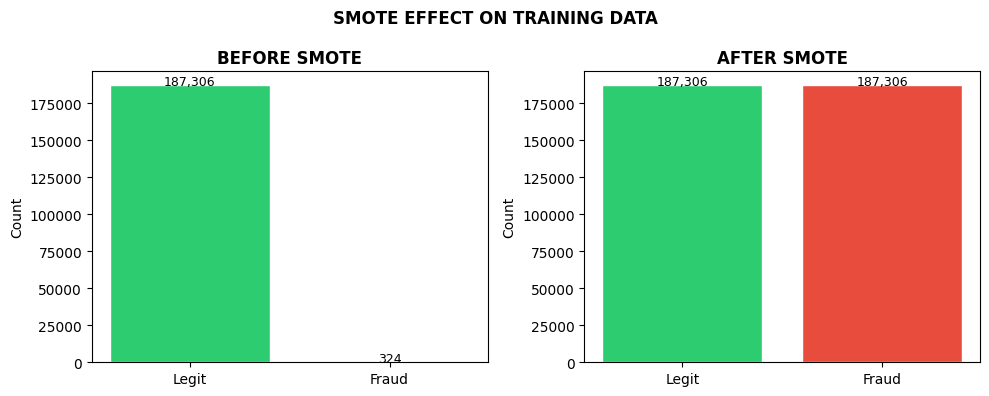

In [8]:
print("BEFORE SMOTE:")
print(f" Train fraud count  :{y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print()
smote=SMOTE(random_state=42,k_neighbors=5)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

print("AFTER SMOTE:")
print(f"    Train shape  :        {X_train_sm.shape}")
print(f"    Fraud count  :        {y_train_sm.sum():,} ({y_train_sm.mean()*100:.1f})%")
print(f"    Legit count  :        {(y_train_sm==0).sum():,}")
print()

fig,axes=plt.subplots(1,2,figsize=(10,4))

for ax,counts,title in[
          (axes[0],Counter(y_train),    "BEFORE SMOTE"),
          (axes[1],Counter(y_train_sm), "AFTER SMOTE")
]:
    ax.bar(["Legit","Fraud"],
           [counts[0],counts[1]],
           color=["#2ecc71","#e74c3c"],edgecolor="white")    
    ax.set_title(title,fontweight="bold")
    ax.set_ylabel("Count")
    for bar,val in zip(ax.patches,[counts[0],counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()+100,
                f"{val:,}",ha="center",fontsize=9)
        
plt.suptitle("SMOTE EFFECT ON TRAINING DATA", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/05_smote_effect.png",dpi=150,bbox_inches="tight")
plt.show()



SAVE EVERYTHING

In [13]:
os.makedirs("../data/processed",exist_ok=True)


joblib.dump(X_train_sm, "../data/processed/X_train.pkl")
joblib.dump(y_train_sm, "../data/processed/y_train.pkl")
joblib.dump(X_val,      "../data/processed/X_val.pkl " )
joblib.dump(y_val,      "../data/processed/y_val.pkl" )
joblib.dump(X_test,     "../data/processed/X_test.pkl")
joblib.dump(y_test,     "../data/processed/y_test.pkl")

print("SAVED SUCESSFULLY:")
print("  X_tarin.pkl            --SMOTE-BALANCED TRAINING FEATURES")
print("  y_tarin.pkl            --SMOTE-BALANCED TARINING LABELS")
print("  X_val.pkl              --VALIDATION FEATURES")
print("  y_val.pkl              --VALIDATION LABELS")
print("  X_test.pkl             --TEST FEATURES")
print("  y_test.pkl             --TEST LABELS")
print("---------------------------------------------------")
print(f" TRAIN SIZE AFTER SMOTE   :{X_train_sm.shape}")
print(f" VALIDATION SIZE          :{X_val.shape}")
print(f" TEST SIZE                :{X_test.shape}")

SAVED SUCESSFULLY:
  X_tarin.pkl            --SMOTE-BALANCED TRAINING FEATURES
  y_tarin.pkl            --SMOTE-BALANCED TARINING LABELS
  X_val.pkl              --VALIDATION FEATURES
  y_val.pkl              --VALIDATION LABELS
  X_test.pkl             --TEST FEATURES
  y_test.pkl             --TEST LABELS
---------------------------------------------------
 TRAIN SIZE AFTER SMOTE   :(374612, 31)
 VALIDATION SIZE          :(40215, 31)
 TEST SIZE                :(56962, 31)


SUMMARY


## Feature Engineering Summary — Day 2

**New features created:**
- Amount_log : log transform of Amount
- Hour       : hour of day from Time
- Is_night   : 1 if between 10pm–5am

**Splits:**
- Train      : ___ rows
- Validation : ___ rows
- Test       : ___ rows

**SMOTE result:**
- Before: ___ fraud samples (0.17%)
- After : ___ fraud samples (50%)

**Key decisions made:**
- Scaled only Amount_log, Hour, Is_night (V features already scaled)
- fit_transform on train only — prevents data leakage
- SMOTE only on train — val and test stay real distribution

**Ready for Day 3:** Train XGBoost + LightGBM